
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


### 📥 **ดาวน์โหลดไฟล์ตัวอย่าง `example.tif`**

เพื่อให้โค้ดตัวอย่างด้านล่างสามารถทำงานได้ เราจะดาวน์โหลดไฟล์ภาพ `.tif` ตัวอย่างมาเก็บไว้ใน Colab ก่อน

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GEE_Downloads/S2_NakhonNayok_2023.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 2054, 'height': 2005, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 101.1178718101014,
       0.0, -8.983152841195215e-05, 14.310072644495566)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


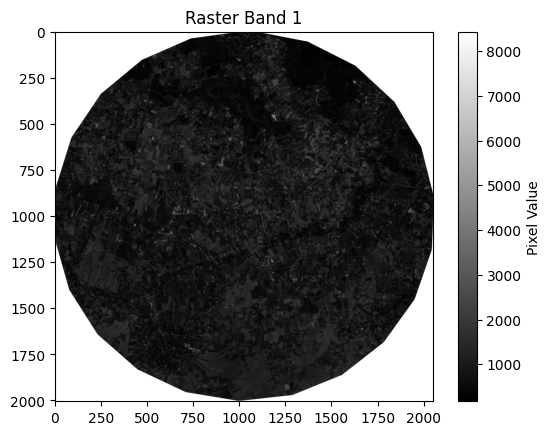

In [ ]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


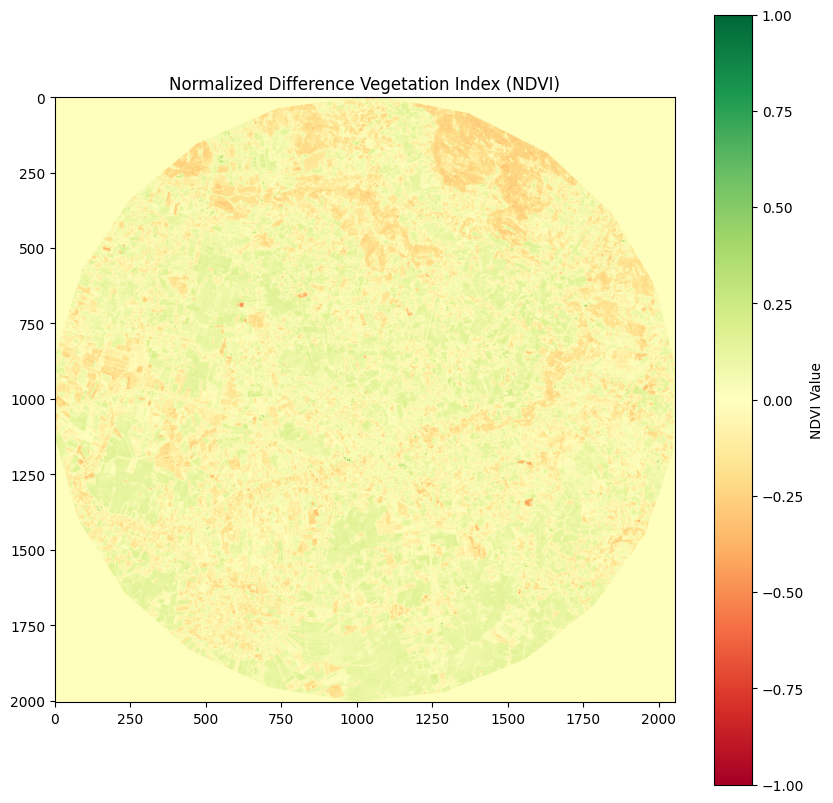

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    # จากการตรวจสอบ metadata ก่อนหน้า:
    # แบนด์ 1: B4 (สมมติว่าเป็น NIR)
    # แบนด์ 2: B3 (สมมติว่าเป็น Red)
    # แบนด์ 3: B2 (Green)
    nir = dataset.read(1).astype(float)  # ใช้แบนด์ 1 สำหรับ NIR (B4)
    red = dataset.read(2).astype(float)  # ใช้แบนด์ 2 สำหรับ Red (B3)

# คำนวณ NDVI
# จัดการกับค่า NaN โดยการแทนที่ด้วย 0 ก่อนคำนวณ เพื่อหลีกเลี่ยงการเกิด NaN ในผลลัพธ์
# หรือสามารถใช้ np.nan_to_num เพื่อแปลง NaN เป็น 0
nir = np.nan_to_num(nir, nan=0.0)
red = np.nan_to_num(red, nan=0.0)

# หลีกเลี่ยงการหารด้วยศูนย์และจัดการค่าที่อาจทำให้เกิด Inf
denominator = (nir + red)
# แทนที่ค่า 0 ใน denominator ด้วยค่าเล็กๆ เพื่อหลีกเลี่ยง ZeroDivisionError
denominator[denominator == 0] = 1e-10

ndvi = (nir - red) / denominator

# แสดงผล NDVI
plt.figure(figsize=(10, 10))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()


## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [ ]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [ ]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
# ตรวจสอบให้แน่ใจว่าไฟล์ 'boundary.shp' อยู่ใน Colab หรือระบุพาธที่ถูกต้องจาก Google Drive
shapefile_path = "/content/drive/MyDrive/GEE_Downloads/Thailand"  # <--- แก้ไขพาธที่นี่ให้ถูกต้อง

# โหลดเลเยอร์ 'Province' และกรองเพื่อเลือกขอบเขตของจังหวัดนครนายก
gdf = gpd.read_file(shapefile_path, layer='Province')

# พิมพ์ชื่อคอลัมน์ทั้งหมดเพื่อตรวจสอบว่าคอลัมน์สำหรับชื่อจังหวัดคือชื่ออะไร
print("Available columns in GeoDataFrame:", gdf.columns)

# พิมพ์ชื่อจังหวัดที่มีอยู่ในคอลัมน์ PROVINCE_E และ PROVINCE_T เพื่อตรวจสอบการสะกด
print("Unique province names in PROVINCE_E:", gdf['PROVINCE_E'].unique())
print("Unique province names in PROVINCE_T:", gdf['PROVINCE_T'].unique())

# กรองเพื่อเลือกขอบเขตของจังหวัดนครนายก โดยใช้ 'PROVINCE_E' และชื่อภาษาอังกฤษที่ถูกต้อง
nakhon_nayok_boundary = gdf[gdf['PROVINCE_E'] == 'NAKHON NAYOK']

if nakhon_nayok_boundary.empty:
    raise ValueError("ไม่พบขอบเขตของจังหวัดนครนายกในเลเยอร์ 'Province' หรือชื่อคอลัมน์ไม่ถูกต้อง")

geometry = [mapping(nakhon_nayok_boundary.geometry.iloc[0])]

# เปิดภาพ Raster เพื่อตรวจสอบ CRS และขอบเขต
with rasterio.open(raster_path) as src:
    print(f"Raster CRS: {src.crs}")
    print(f"Raster Bounds: {src.bounds}")
    print(f"GeoDataFrame CRS: {nakhon_nayok_boundary.crs}")
    print(f"GeoDataFrame Bounds: {nakhon_nayok_boundary.total_bounds}")

    # หาก CRS ไม่ตรงกัน ให้ reproject GeoDataFrame
    if src.crs != nakhon_nayok_boundary.crs:
        print(f"Reprojecting GeoDataFrame from {nakhon_nayok_boundary.crs} to {src.crs}")
        nakhon_nayok_boundary = nakhon_nayok_boundary.to_crs(src.crs)
        geometry = [mapping(nakhon_nayok_boundary.geometry.iloc[0])]
        print(f"Reprojected GeoDataFrame Bounds: {nakhon_nayok_boundary.total_bounds}")

    # ตัดภาพ Raster
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform, "nodata": None})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")

Available columns in GeoDataFrame: Index(['PROV_CODE', 'PROVINCE_E', 'PROVINCE_T', 'geometry'], dtype='object')
Unique province names in PROVINCE_E: ['KRABI' 'KANCHANABURI' 'KALASIN' 'KAMPAENG PHET' 'KHON KAEN'
 'CHANTHABURI' 'CHACHOENGSAO' 'CHONBURI' 'CHAINAT' 'CHAIYAPHUM' 'CHUMPHON'
 'CHIANG RAI' 'CHIANG MAI' 'TRANG' 'TRAD' 'TAK' 'YASOTHON' 'NAKHON NAYOK'
 'NAKHON PATHOM' 'NAKHON PHANOM' 'NAKHON RATCHASIMA' 'NAKHON SI THAMMARAT'
 'NAKHON SAWAN' 'NONTHABURI' 'NARATHIWAT' 'NAN' 'BURIRAM' 'PATHUM THANI'
 'PRACHUAP KHILIKHAN' 'PHACHINBURI' 'PATTANI' 'BANGKOK'
 'PHRA NAKHON SI AYUDHYA' 'PHANGNGA' 'PHATTHALUNG' 'PHICHIT' 'PHITSANULOK'
 'PHETCHABURI' 'PHETCHABUN' 'PHRAE' 'PHUKET' 'MAHA SARAKHAM'
 'MAE HONG SON' 'YALA' 'ROI ET' 'RANONG' 'RAYONG' 'RATCHABURI' 'LOPBURI'
 'LAMPANG' 'LAMPHUN' 'LOEI' 'SI SAKET' 'SAKON NAKHON' 'SONGKHLA' 'SATUN'
 'SAMUT PRAKARN' 'SAMUT SONGKHAM' 'SAMUT SAKHON' 'SARABURI' 'SINGBURI'
 'SUKHOTHAI' 'SUPHANBURI' 'SURAT THANI' 'SURIN' 'NONG KHAI' 'ANG THONG'
 'UDON THAN


# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


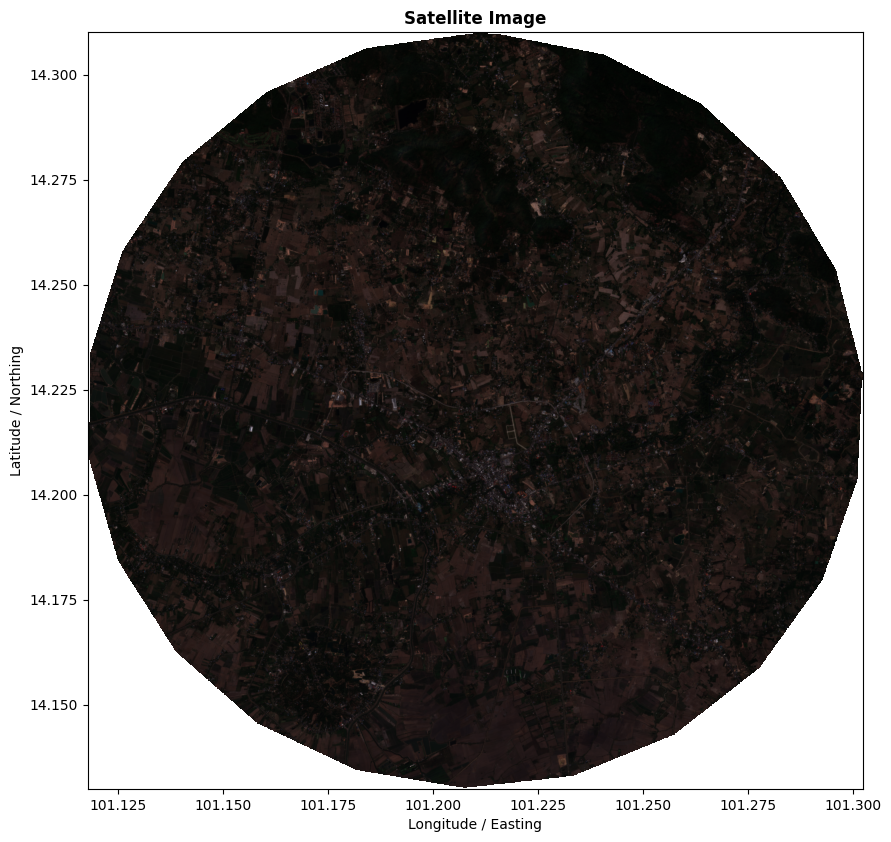

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# ระบุพาร์ทของไฟล์ Raster
raster_path = '/content/drive/MyDrive/GEE_Downloads/S2_NakhonNayok_2023.tif'

# เปิดไฟล์ด้วย rasterio
with rasterio.open(raster_path) as src:
    fig, ax = plt.subplots(figsize=(10, 10))

    # แสดงผลภาพ (หากเป็นภาพหลายแบนด์ สามารถระบุแบนด์ที่ต้องการแสดงได้ เช่น src.read(1))
    show(src, ax=ax, title='Satellite Image')

    # แสดงรายละเอียดแกน X, Y (ซึ่งจะเป็นค่าพิกัดตาม CRS ของภาพ)
    ax.set_xlabel('Longitude / Easting')
    ax.set_ylabel('Latitude / Northing')

    plt.show()

In [ ]:
import rasterio

raster_path = '/content/drive/MyDrive/GEE_Downloads/S2_NakhonNayok_2023.tif'

with rasterio.open(raster_path) as src:
    meta = src.meta
    print("=== Raster Metadata ===")
    for key, value in meta.items():
        print(f"{key}: {value}")



=== Raster Metadata ===
driver: GTiff
dtype: float64
nodata: None
width: 2054
height: 2005
count: 3
crs: EPSG:4326
transform: | 0.00, 0.00, 101.12|
| 0.00,-0.00, 14.31|
| 0.00, 0.00, 1.00|


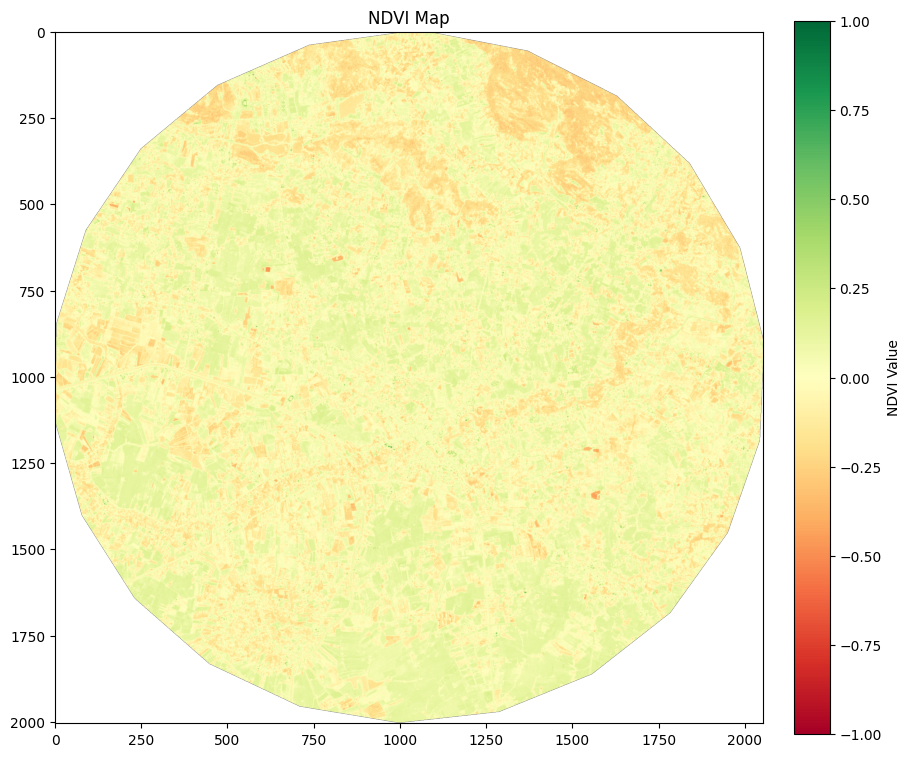

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

raster_path = '/content/drive/MyDrive/GEE_Downloads/S2_NakhonNayok_2023.tif'

with rasterio.open(raster_path) as src:
    # อ่านแบนด์ Red และ NIR (เปลี่ยนเลข index ตามโครงสร้างแบนด์ของดาวเทียมที่ใช้)
    # rasterio index เริ่มที่ 1
    # แก้ไข: ไฟล์มีเพียง 3 แบนด์ จึงใช้แบนด์ 1 และ 2 แทน (ตามการทดลองใน Example 3)
    nir = src.read(1).astype('float32') # สมมติว่าแบนด์ 1 คือ NIR
    red = src.read(2).astype('float32') # สมมติว่าแบนด์ 2 คือ Red

# จัดการกับการหารด้วยศูนย์ (Division by zero) เพื่อป้องกัน Warning
np.seterr(divide='ignore', invalid='ignore')

# คำนวณ NDVI: (NIR - Red) / (NIR + Red)
ndvi = np.where(
    (nir + red) == 0.,
    0,
    (nir - red) / (nir + red)
)

# พล็อตผลลัพธ์ NDVI
fig, ax = plt.subplots(figsize=(10, 10))
# ใช้ Colormap แบบ 'RdYlGn' (Red-Yellow-Green) ซึ่งเหมาะกับดัชนีพืชพรรณ
im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)

ax.set_title('NDVI Map')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='NDVI Value')
plt.show()

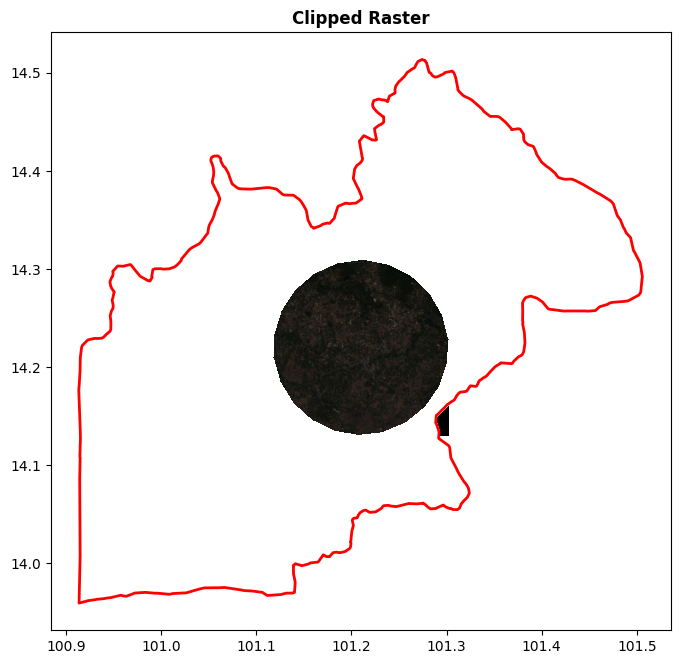

In [39]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show

raster_path = '/content/drive/MyDrive/GEE_Downloads/S2_NakhonNayok_2023.tif'
shapefile_path = '/content/drive/MyDrive/GEE_Downloads/nakonyayok'

# 1. โหลดข้อมูล Shapefile ด้วย GeoPandas
gdf = gpd.read_file(shapefile_path)

with rasterio.open(raster_path) as src:
    # 2. ตรวจสอบและแปลง CRS ของ Shapefile ให้ตรงกับ Raster (สำคัญมาก)
    if gdf.crs != src.crs:
        gdf = gdf.to_crs(src.crs)

    # 3. แปลง Geometry จาก GeoDataFrame ให้อยู่ในรูปแบบ list ของ GeoJSON-like dict
    geometries = [geom for geom in gdf.geometry]

    # 4. ตัดภาพ (Clip)
    # crop=True หมายถึงให้หดขนาดกรอบ (Bounding Box) ของภาพผลลัพธ์ให้พอดีกับ Shapefile
    out_image, out_transform = mask(src, geometries, crop=True)
    out_meta = src.meta.copy()

# 5. อัปเดต Metadata สำหรับภาพใหม่ที่ถูกตัดแล้ว
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# 6. บันทึกผลลัพธ์เป็นไฟล์ใหม่
output_path = 'clipped_image.tif'
with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(out_image)

# 7. แสดงผลภาพที่ถูกตัด
with rasterio.open(output_path) as clipped_src:
    fig, ax = plt.subplots(figsize=(8, 8))
    show(clipped_src, ax=ax, title='Clipped Raster')
    # นำขอบเขต Shapefile มาวางทับเพื่อตรวจสอบความถูกต้อง
    gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)
    plt.show()